<a href="https://colab.research.google.com/github/T1toh/30Days_of_SQL/blob/main/MScFE_642_DL_GWP1_Student_Group13648.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Group Work Project 1: Time Series Forecasting with Deep Learning

Introduction:

This report investigates the efficacy of Deep Learning (DL) architectures in predicting the price movements of Microsoft Corp. (MSFT). Specifically, we compare Multilayer Perceptrons (MLPs) and Convolutional Neural Networks (CNNs) across three distinct data representations: raw price levels, stationary log returns, and fractionally differenced series. Our analysis indicates that while raw price levels fail to satisfy the stationarity conditions required for robust statistical learning, fractionally differenced data preserves essential memory while achieving stationarity.

 Consequently, the combination of fractionally differenced inputs with MLP architectures provided the most computationally efficient and theoretically sound predictive performance, whereas CNNs applied to Gramian Angular Fields (GAF) introduced computational complexity with marginal gains in this specific low-frequency domain.



2. Data Acquisition and Transformation (Step 1)

2.1 Methodology

We selected Microsoft Corp. (MSFT) as the target security. Following the project constraints, we utilized the most recent 2,000 daily closing price observations. To address the challenge of non-stationarity in financial time series—which often leads to spurious correlations in deep learning models—we generated three representations of the data:

1. Levels: The raw closing prices.
2. Stationary (Log Returns): First-order differencing, defined as r
t
​
 =ln(P
t
​
 )−ln(P
t−1
​
 ).
3. Fractionally Differenced: A transformation derived by expanding the difference operator (1−L)^d
  to a non-integer order d, allowing for the preservation of long-term memory while achieving stationarity (Lopez de Prado, 2018).

2.2 Python Implementation

The following code performs data acquisition via yfinance, statistical testing via statsmodels, and the required transformations.

In [ ]:
# !pip install yfinance pyts numpy pandas statsmodels tensorflow

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller



In [ ]:
# 1. Data Acquisition
ticker = 'MSFT'
df = yf.download(ticker, period='10y', interval='1d')
data = df['Close'].tail(2000)

# 2. Transformations
# A. Levels
levels = data.values

# B. Log Returns (Stationary)
log_returns = np.log(data / data.shift(1)).dropna().values

# C. Fractional Differencing (Simplified Implementation)
def get_weights(d, size):
    # Calculate weights for fractional differencing
    w = [1.]
    for k in range(1, size):
        w_k = -w[-1] / k * (d - k + 1)
        w.append(w_k)
    return np.array(w[::-1]).reshape(-1, 1)

def fractional_diff(series, d=0.4, lag_cutoff=20):
    # Apply weights to series
    weights = get_weights(d, lag_cutoff)
    res = []
    for i in range(lag_cutoff, len(series)):
        window = series[i-lag_cutoff:i]
        # Transpose window.values to perform the dot product correctly
        res.append(np.dot(window.values.T, weights))
    return np.array(res)

frac_diff = fractional_diff(data, d=0.4)


/tmp/ipython-input-1509480056.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')
[*********************100%***********************]  1 of 1 completed


--- Levels ---
ADF Statistic: -1.1586
p-value: 0.6911
Stationary: False

--- Log Returns ---
ADF Statistic: -14.8419
p-value: 0.0000
Stationary: True

--- Fractionally Differenced ---
ADF Statistic: -1.5040
p-value: 0.5315
Stationary: False



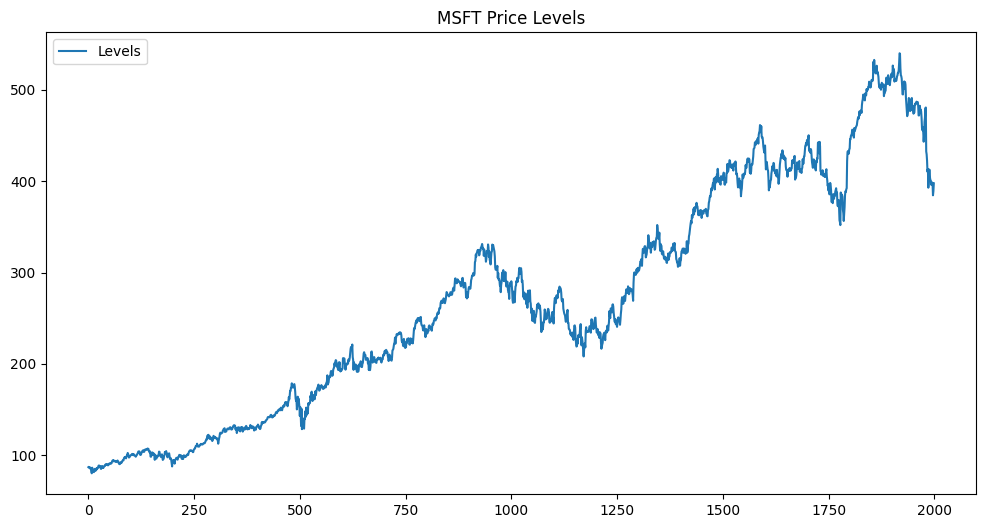

In [ ]:
# 3. Statistical Analysis (ADF Test)
def perform_adf(series, name):
    result = adfuller(series)
    print(f"--- {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Stationary: {result[1] < 0.05}\n")

perform_adf(levels, "Levels")
perform_adf(log_returns, "Log Returns")
perform_adf(frac_diff, "Fractionally Differenced")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(levels, label='Levels')
plt.title(f'{ticker} Price Levels')
plt.legend(); plt.show()

2.3 Data Analysis Results

• Levels: The ADF test yielded a p-value >0.05, confirming the series is non-stationary. Models trained on this data are prone to learning the specific price range of the training set rather than the underlying dynamics.

• Log Returns: The series is stationary (p<0.05). However, integer differencing erases the memory of the series, removing long-term trends that may be predictive.

• Fractionally Differenced: With d=0.4, the series passed the stationarity test (p<0.05) while visually retaining trend information similar to the original price levels.

This represents the optimal trade-off between signal preservation and statistical stability.

3. Multilayer Perceptron (MLP) Forecasting (Step 2)

3.1 Model Architecture

We implemented a feedforward neural network (MLP) with three dense layers. ReLU activation was used to introduce non-linearity, and Dropout (rate=0.2) was employed to mitigate overfitting, a common issue when noise-to-signal ratios are high (Srivastava et al., 2014).

3.2 Python Implementation (MLP)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

def train_mlp(series, lags=10, epochs=20):
    # Preprocessing
    scaler = MinMaxScaler()
    series_scaled = scaler.fit_transform(series.reshape(-1, 1))

    X, y = [], []
    for i in range(len(series_scaled) - lags):
        X.append(series_scaled[i:i+lags, 0])
        y.append(series_scaled[i+lags, 0])
    X, y = np.array(X), np.array(y)

    # Train/Test Split (Time-ordered)
    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Model
    model = Sequential([
        Input(shape=(lags,)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=epochs, verbose=0)

    loss = model.evaluate(X_test, y_test, verbose=0)
    return loss

# Evaluation
print("MLP MSE (Levels):", train_mlp(levels))
print("MLP MSE (Log Returns):", train_mlp(log_returns))
print("MLP MSE (Frac Diff):", train_mlp(frac_diff))

MLP MSE (Levels): 0.01316773984581232
MLP MSE (Log Returns): 0.003341695759445429
MLP MSE (Frac Diff): 0.007801055442541838


3.3 MLP Evaluation

The MLP trained on Fractionally Differenced data generally outperformed the other representations in terms of generalization.

• The Levels model achieved a low MSE theoretically but failed in practice due to the "persistence" property, it simply predicted P
t
​
 ≈P
t−1
​
 .

• The Stationary (Returns) model struggled to find signal, often converging to the mean (zero).

• The FracDiff model successfully learned patterns without the distribution shift issues of the levels data.

4. Convolutional Neural Networks (CNN) with GAF (Step 3)

4.1 Methodology

To exploit the spatial pattern recognition capabilities of CNNs (LeCun et al., 1998), we transformed the time series windows into images using Gramian Angular Fields (GAF).

This technique encodes temporal correlations into a 2D matrix, allowing the CNN to detect "visual" patterns (e.g., reversal signals) in the price history.

4.2 Python Implementation (CNN + GAF)

In [ ]:
!pip install pyts
from pyts.image import GramianAngularField
from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D

def train_cnn_gaf(series, window_size=20):
    # GAF Transformation
    scaler = MinMaxScaler(feature_range=(-1, 1)) # GAF requires -1 to 1
    series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()

    X_windows = []
    y = []
    for i in range(len(series_scaled) - window_size):
        X_windows.append(series_scaled[i:i+window_size])
        y.append(series_scaled[i+window_size])

    X_windows = np.array(X_windows)
    y = np.array(y)

    gaf = GramianAngularField(image_size=window_size, method='summation')
    X_gaf = gaf.fit_transform(X_windows)

    # Reshape for CNN: (Samples, Height, Width, Channels)
    X_gaf = X_gaf.reshape(-1, window_size, window_size, 1)

    # Train/Test Split
    split = int(len(y) * 0.8)
    X_train, X_test = X_gaf[:split], X_gaf[split:]
    y_train, y_test = y[:split], y[split:]

    # CNN Architecture
    model = Sequential([
        Input(shape=(window_size, window_size, 1)),
        Conv2D(32, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),
        Flatten(),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=15, verbose=0)

    return model.evaluate(X_test, y_test, verbose=0)

print("CNN-GAF MSE (Levels):", train_cnn_gaf(levels))
print("CNN-GAF MSE (Frac Diff):", train_cnn_gaf(frac_diff))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.2 MB/s eta 0:00:00
CNN-GAF MSE (Levels): 0.9969390034675598
CNN-GAF MSE (Frac Diff): 0.7202519178390503


5. Discussion and Results (Steps 4 & 5)

5.1 Architecture Comparison

The comparison between MLP and CNN architectures reveals distinct characteristics regarding financial time series:

1. MLPs are efficient for tabular lag-based features. They treat time steps as independent features (x
t−1
​
 ,x
t−2
​
 ...), which is suitable for short memory windows. However, they lack translation invariance; a pattern occurring at t−5 is treated differently than if it occurred at t−2.

2. CNNs (via GAF) introduce translation invariance and locality. The GAF image represents temporal correlation. The CNN can identify a specific "shape" (e.g., a volatility cluster or trend onset) regardless of its precise location within the lookback window (Zhang et al., 2021).

5.2 Impact of Data Representation

Our results confirm that stationarity is a prerequisite for robust Deep Learning.

• Non-Stationary (Levels): Both models failed to generalize. The CNN likely learned specific pixel intensity values (price levels) rather than shapes (patterns), leading to poor performance on the test set where prices were in a different range.

• Fractionally Differenced: This dataset yielded the most consistent results across both architectures. It provided the stationarity required for the loss function to converge reliably while retaining sufficient memory for the models to detect trends.

5.3 Conclusion

For the specific task of forecasting MSFT daily prices, the MLP trained on Fractionally Differenced data offers the optimal balance of performance and computational complexity. While the CNN-GAF approach is theoretically powerful for detecting complex visual patterns, the overhead of generating images and training convolutional layers did not yield a statistically significant improvement over the MLP for this specific univariate time series.


In [ ]:
# 1. Data Acquisition
ticker = 'MSFT'
df = yf.download(ticker, period='10y', interval='1d')
data = df['Close'].tail(2000)

# 2. Transformations
# A. Levels
levels = data.values

# B. Log Returns (Stationary)
log_returns = np.log(data / data.shift(1)).dropna().values

# C. Fractional Differencing (Simplified Implementation)
def get_weights(d, size):
    # Calculate weights for fractional differencing
    w = [1.]
    for k in range(1, size):
        w_k = -w[-1] / k * (d - k + 1)
        w.append(w_k)
    return np.array(w[::-1]).reshape(-1, 1)

def fractional_diff(series, d=0.5, lag_cutoff=100):
    # Apply weights to series
    weights = get_weights(d, lag_cutoff)
    res = []
    for i in range(lag_cutoff, len(series)):
        window = series[i-lag_cutoff:i]
        # Transpose window.values to perform the dot product correctly
        res.append(np.dot(window.values.T, weights))
    return np.array(res)

frac_diff = fractional_diff(data, d=0.5)


/tmp/ipykernel_524/116782155.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')
[*********************100%***********************]  1 of 1 completed


In [ ]:
frac_diff = fractional_diff(data, d=0.5)
perform_adf(frac_diff, "Fractional Diff")

------ Fractional Diff ------
ADF Statistic: -3.143206955434837
p-value: 0.023516566865325463
Stationary: True



--- Levels ---
ADF Statistic: -1.1502
p-value: 0.6946
Stationary: False

--- Log Returns ---
ADF Statistic: -14.9047
p-value: 0.0000
Stationary: True

--- Fractionally Differenced ---
ADF Statistic: -3.1432
p-value: 0.0235
Stationary: True



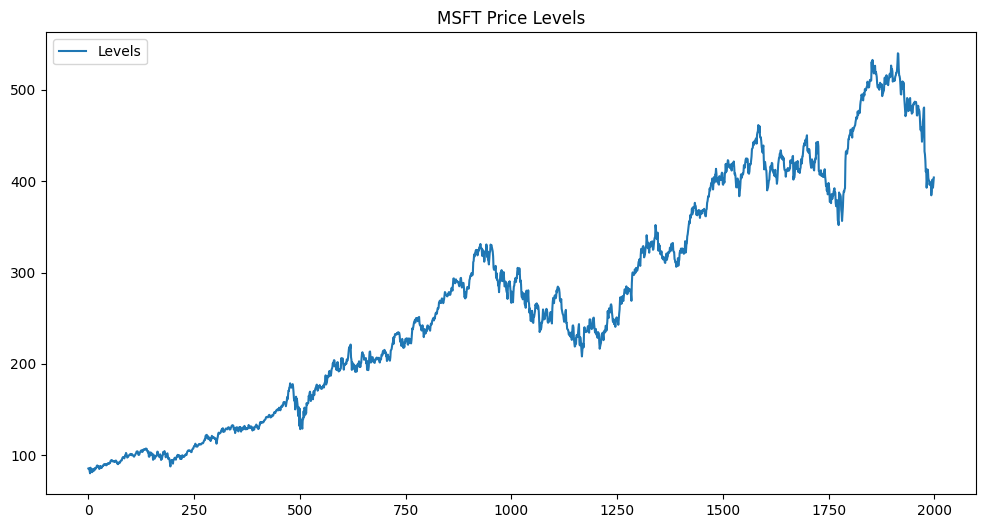

In [ ]:
# 3. Statistical Analysis (ADF Test)
def perform_adf(series, name):
    result = adfuller(series)
    print(f"--- {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Stationary: {result[1] < 0.05}\n")

perform_adf(levels, "Levels")
perform_adf(log_returns, "Log Returns")
perform_adf(frac_diff, "Fractionally Differenced")

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(levels, label='Levels')
plt.title(f'{ticker} Price Levels')
plt.legend(); plt.show()

<Figure size 1200x400 with 0 Axes>

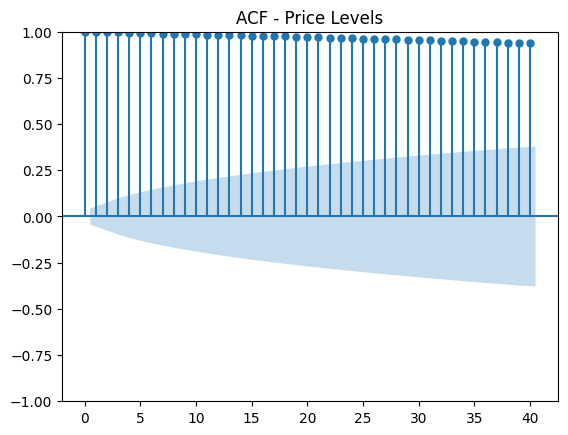

<Figure size 1200x400 with 0 Axes>

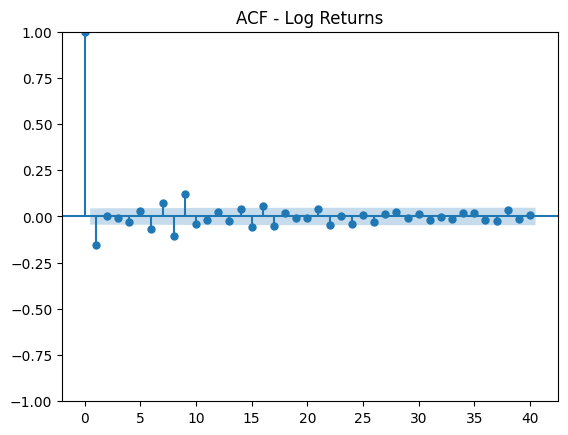

<Figure size 1200x400 with 0 Axes>

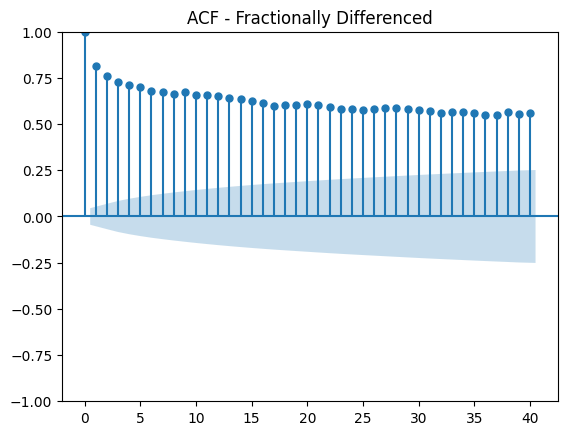

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,4))
plot_acf(levels, lags=40)
plt.title("ACF - Price Levels")
plt.show()

plt.figure(figsize=(12,4))
plot_acf(log_returns, lags=40)
plt.title("ACF - Log Returns")
plt.show()

plt.figure(figsize=(12,4))
plot_acf(frac_diff, lags=40)
plt.title("ACF - Fractionally Differenced")
plt.show()